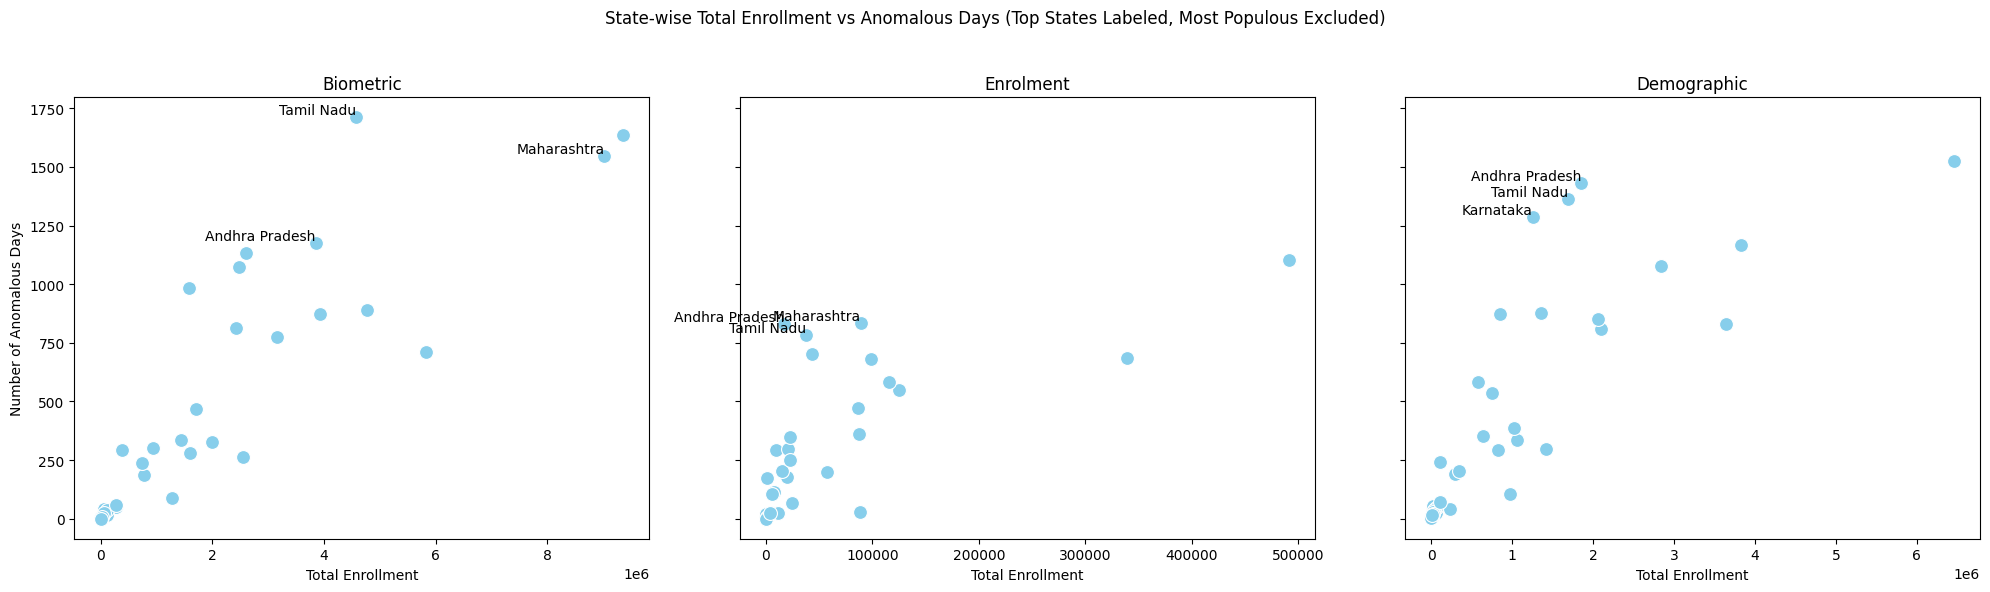

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset info: map their age columns to a common format
datasets = {
    "Biometric": {"file": "./biometric.csv", "col_map": {"bio_age_5_17": "age_5_17", "bio_age_17_": "age_17_"}},
    "Enrolment": {"file": "./enrolment.csv", "col_map": {"age_5_17": "age_5_17", "age_18_greater": "age_17_"}},
    "Demographic": {"file": "./demographic.csv", "col_map": {"demo_age_5_17": "age_5_17", "demo_age_17_": "age_17_"}}
}

# Bad state values to remove
bad_values = [
    "Darbhanga", "Puttenahalli", "Balanagar", "Jaipur",
    "Madanapalle", "Nagpur", "Raja Annamalai Puram", "100000","BALANAGAR"
]

# State name standardization
state_mapping = {
    "west Bengal": "West Bengal", "West  Bengal": "West Bengal", "Westbengal": "West Bengal",
    "WEST BENGAL": "West Bengal", "West Bangal": "West Bengal", "West bengal": "West Bengal",
    "WESTBENGAL": "West Bengal", "West Bengli": "West Bengal",
    "odisha": "Odisha", "ODISHA": "Odisha", "Orissa": "Odisha",
    "andhra pradesh": "Andhra Pradesh",
    "Jammu & Kashmir": "Jammu and Kashmir",
    "Chhatisgarh": "Chhattisgarh",
    "Pondicherry": "Puducherry",
    "Uttaranchal": "Uttarakhand",
    "Daman & Diu": "Dadra and Nagar Haveli and Daman and Diu",
    "Daman and Diu": "Dadra and Nagar Haveli and Daman and Diu",
    "Dadra & Nagar Haveli": "Dadra and Nagar Haveli and Daman and Diu",
    "Dadra and Nagar Haveli": "Dadra and Nagar Haveli and Daman and Diu",
    "Andaman & Nicobar Islands": "Andaman and Nicobar Islands",
}

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

for idx, (name, info) in enumerate(datasets.items()):
    df = pd.read_csv(info["file"])
    
    # Remove bad values
    df = df[~df["state"].isin(bad_values)]
    
    # Standardize state names
    df["state"] = df["state"].replace(state_mapping)
    
    # Rename age columns to common names
    df = df.rename(columns=info["col_map"])
    
    # Drop duplicates
    df = df.drop_duplicates()
    
    # Aggregate duplicates by pincode and date
    df = df.groupby(["pincode", "date"], as_index=False).agg({
        "state": "first",
        "age_5_17": "sum",
        "age_17_": "sum"
    })
    
    # Total enrollment & rolling mean
    df["total_enrollment"] = df["age_5_17"] + df["age_17_"]
    df["rolling_mean"] = df.groupby("pincode")["total_enrollment"].transform(
        lambda x: x.rolling(7, min_periods=1).mean()
    )
    
    # Z-score for anomaly detection
    df["z_score"] = ((df["total_enrollment"] - df["rolling_mean"]) /
                     df.groupby("pincode")["total_enrollment"].transform("std"))
    df["anomaly_flag"] = (df["z_score"].abs() > 3).astype(int)
    
    # State summary
    state_summary = df.groupby("state").agg(
        total_enrollment=("total_enrollment", "sum"),
        anomalies=("anomaly_flag", "sum")
    ).reset_index()
    
    # Find the most populous state (highest total enrollment)
    most_populous_state = state_summary.loc[state_summary["total_enrollment"].idxmax(), "state"]
    
    # Select top 3 anomalous states excluding the most populous
    top_states = state_summary[state_summary["state"] != most_populous_state].nlargest(3, "anomalies")
    
    # Scatter plot
    ax = axes[idx]
    sns.scatterplot(
        data=state_summary,
        x="total_enrollment",
        y="anomalies",
        s=100,
        color="skyblue",
        ax=ax
    )
    
    # Label top anomalous states
    for i, row in top_states.iterrows():
        ax.text(
            row["total_enrollment"],
            row["anomalies"],
            row["state"],
            fontsize=10,
            ha="right",
            va="bottom"
        )
    
    ax.set_title(name)
    ax.set_xlabel("Total Enrollment")
    if idx == 0:
        ax.set_ylabel("Number of Anomalous Days")

plt.suptitle("State-wise Total Enrollment vs Anomalous Days (Top States Labeled, Most Populous Excluded)")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
